### Bayesian MC dropout query strategies

Bayesian query strategies use Monte Carlo (MC) dropout to approximate uncertainty in deep learning models. This works by computing multiple forward passes through a neural network with the dropout layers activated. For this example we are going to use a subset of [_MNIST_](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits) dataset, loaded from _sklearn_.

In [1]:
import numpy as np
import torch
from skorch import NeuralNetClassifier
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from activelearning.AL_cycle import plot_results, strategy_comparison
# from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.bayesian.mc_bald import mc_bald
from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.bayesian.mc_max_meanstd import mc_max_meanstd
from activelearning.queries.bayesian.mc_max_varratios import mc_max_varratios
from activelearning.queries.hybrid.badge import query_badge
from activelearning.queries.representative.random_query import query_random
from activelearning.utils.skorch_nnet import reshapedVGG

torch.manual_seed(123)
np.random.seed(123)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import sys
import os
import numpy as np
import torch

PROJECT_ROOT = os.path.abspath("../..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from al_data_process.data_preprocess import create_windowed_ts, map_class_label_to_idx
from al_data_process.dataset import stratified_sampling_train_val

window_length = 0.4
overlap = 0.25

invalid_classes = [14]
Xt_acc, Xt_gyr, Xt_mag, Xt_mic, y_org_label = create_windowed_ts(data_path="../../tool-tracking-data/",
                                                                     tool="electric_screwdriver",
                                                                     invalid_classes=invalid_classes,
                                                                     window_length = window_length,
                                                                     overlap = overlap)

all_classes, counts = np.unique(y_org_label, return_counts=True)

Xt_acc = Xt_acc[:, :, 1:].astype(np.float32)
Xt_gyr = Xt_gyr[:, :, 1:].astype(np.float32)
Xt_mag = Xt_mag[:, :, 1:].astype(np.float32)
Xt_mic = Xt_mic[:, :, 1:].astype(np.float32)

y = map_class_label_to_idx(y_org_label)

train_set, test_set = stratified_sampling_train_val(torch.from_numpy(Xt_acc),
                                                  torch.from_numpy(Xt_gyr),
                                                  torch.from_numpy(Xt_mag),
                                                  torch.from_numpy(Xt_mic),
                                                  torch.tensor(y))


X_pool = np.empty(len(train_set), dtype=object)
y_pool = np.empty(len(train_set))
for i in range(len(train_set)):
    X_pool[i] = train_set[i][0]
    y_pool[i] = train_set[i][1]


X_test = np.empty(len(test_set), dtype=object)
y_test = np.empty(len(test_set))
for i in range(len(test_set)):
    X_test[i] = test_set[i][0]
    y_test[i] = test_set[i][1]


[INFO] Preparing data from:
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read data:   0%|          | 0/16 [00:00<?, ?it/s]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read data:  12%|█▎        | 2/16 [00:00<00:01,  7.36it/s, file=MIC-03-8000.csv]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-01-155.087.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-03-102.291.csv) and from the timestamps differ by 0.001Hz



...

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-02-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 16.81it/s, file=data-02.annotation]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-02-154.679.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/

[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 11.04it/s, file=data-02.annotation]


[INFO] Finished with 4 measurement(s).
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
Segment: 100%|██████████| 19380/19380 [00:00<00:00, 109556.58it/s]
[2 3 4 5 6 7 8] [ 546  234  199   89   50   59 3606]
count_1_14: 3, count_invalid_classes: 8, count_maj_vote: 46, count_diff_label: 5


We evaluate the performance of the classifier that we are going to use on the complete training set. This will serve as reference metric for the active learning query strategies, as we want to reach the same accuracy / f1 score but with less labeled data.

In [4]:
num_lstm_layers = 1
hidden_size = 32
dropout_p = 0.3
num_classes = 7
lr = 2e-3
batch_size = 16
max_epochs = 100

In [6]:
from model.lstm_classif import LSTM_CLASSIF
from sklearn.metrics import f1_score
from skorch.dataset import CVSplit
from skorch.callbacks import EpochScoring, Checkpoint


def compute_class_weights_from_labels(y, beta=0.999):
    """
    Compute effective number class weights directly from labels.

    Args:
        y: array-like, shape (num_samples,)
           Class labels (int or float, discrete)
        beta: float, smoothing factor

    Returns:
        weights: np.array, shape (num_classes,)
    """
    classes, counts = np.unique(y, return_counts=True)
    classes = classes.astype(int)

    counts = counts.astype(np.float32)
    counts = np.maximum(counts, 1.0)

    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num

    weights = weights / weights.mean()

    num_classes = int(np.max(classes)) + 1
    full_weights = np.zeros(num_classes, dtype=np.float32)
    full_weights[classes] = weights

    return full_weights


class_weights = compute_class_weights_from_labels(y_pool, beta=0.999)
class_weights_tensor = torch.from_numpy(class_weights).float()


def collate_fn(batch):
    # separate features and labels
    x_batch, y_batch = zip(*batch)  # x_batch = list of tuples, y_batch = list of labels

    # transpose modalities
    acc, gyr, mag, mic = zip(*x_batch)  # each is a tuple of tensors

    # stack tensors along batch dimension (dim=0)
    acc = torch.stack(acc, dim=0)  # shape: (batch, time, features)
    gyr = torch.stack(gyr, dim=0)
    mag = torch.stack(mag, dim=0)
    mic = torch.stack(mic, dim=0)

    # convert labels to tensor
    if isinstance(y_batch[0], torch.Tensor):
        y_batch = torch.stack(y_batch).long()  # works if labels are 0-dim tensors
    else:
        y_batch = torch.tensor(y_batch, dtype=torch.long)


    return (acc, gyr, mag, mic), y_batch


classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=class_weights_tensor,
    lr=lr,
    batch_size=batch_size,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=max_epochs,
    device=device,
    # train_loss_best=True,
)

f1_cb = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)


# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(
#         input_size=3,
#         hidden_size=hidden_size,
#         num_layers=num_lstm_layers,
#         num_classes=num_classes,
#         dropout_p=dropout_p,
#     ),
#     criterion=torch.nn.CrossEntropyLoss,
#     criterion__weight=class_weights_tensor,
#     optimizer=torch.optim.Adam,
#     lr=lr,
#     batch_size=batch_size,
#     max_epochs=max_epochs,
#     device=device,

#     # train_split=ValidSplit(0.2, stratified=True),
#     # train_split=CVSplit(0.2, stratified=True),
#     train_split=CVSplit(0.15 / 0.85, stratified=True, random_state=42),

#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,

#     callbacks=[f1_cb, checkpoint],
# )


classifier.fit(X_pool, y_pool)

# classifier.load_params(f_params='best_weights.pt')

goal_acc = classifier.score(X_test, y_test)

y_pred = classifier.predict(X_test)
# print(y_pred.shape)
goal_f1 = f1_score(y_test, y_pred, average="macro")


print(f"Goal Accuracy: {goal_acc}")
print(f"Goal F1 Score: {goal_f1}")



# net = classifier.module_
# net.output_mode = "embedding"
# net.eval()

# with torch.no_grad():
#     emb = torch.cat(list(classifier.forward_iter(X_test, training=False)))

# net.output_mode = "logits"



  epoch    train_loss     dur
-------  ------------  ------
      1        1.4116  1.5554
      2        1.0998  1.5384
      3        0.8638  1.5468
      4        0.7995  1.5258
      5        0.7803  1.5058
      6        0.7197  1.5047
      7        0.6618  1.5137
      8        0.6456  1.5405
      9        0.5746  1.5405
     10        0.5553  1.5428
     11        0.5891  1.5364
     12        0.5203  1.5389
     13        0.5121  1.5418
     14        0.5505  1.5381
     15        0.4965  1.5693
     16        0.4956  1.5737
     17        0.4336  1.5423
     18        0.4589  1.5114
     19        0.4439  1.5324
     20        0.5164  1.5361
     21        0.4362  1.5590
     22        0.4380  1.5547
     23        0.4105  1.5239
     24        0.4091  1.5202
     25        0.3719  1.5329
     26        0.3711  1.5491
     27        0.3713  1.5404
     28        0.3208  1.5384
     29        0.3361  1.5348
     30        0.3854  1.5563
     31        0.3283  1.5388
     32   

In [7]:
n_query = 400
selected_idx = np.random.choice(len(X_pool), size=n_query, replace=False)

X_initial = X_pool[selected_idx]
y_initial = y_pool[selected_idx]

X_pool = np.delete(X_pool, selected_idx, axis=0)
y_pool = np.delete(y_pool, selected_idx, axis=0)

To compare how different query strategies perform, we can use the *strategy_comparison* function and pass the strategies to be used. We can also pass more than one number of instances, to check whether a different batch size influences performance. *plot_results* can be used to immediatly plot the output from *strategy_comparison*, or a custom graph can be created from the scores data frame.

In [ ]:
n_instances = [100]
goal_metric = "f1"
# goal_metric = "acc"

classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    # criterion__weight=class_weights_tensor,
    lr=2e-3,
    batch_size=16,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=100,
    device=device,
)


f1_cb_al = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint_al = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)

# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(
#         input_size=3,
#         hidden_size=hidden_size,
#         num_layers=num_lstm_layers,
#         num_classes=num_classes,
#         dropout_p=dropout_p,
#     ),
#     criterion=torch.nn.CrossEntropyLoss,
#     # criterion__weight=class_weights_tensor,
#     optimizer=torch.optim.Adam,
#     lr=lr,
#     batch_size=batch_size,
#     max_epochs=max_epochs,
#     device=device,

#     # Use stratified validation split
#     # train_split=ValidSplit(0.2, stratified=True),
#     train_split=CVSplit(0.15 / 0.85),

#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,

#     callbacks=[f1_cb_al, checkpoint_al],
# )


scores = strategy_comparison(
    X_train=X_initial,
    y_train=y_initial,
    X_pool=X_pool,
    y_pool=y_pool,
    X_test=X_test,
    y_test=y_test,
    # classifier="nnet_bo",
    classifier=classifier,
    # query_type="uncertainty",
    # query_strategies=[mc_bald, mc_max_entropy, mc_max_varratios, query_random, mc_max_meanstd],
    # query_strategies=[query_random, mc_max_entropy],
    # query_strategies=[mc_max_entropy],
    query_strategies=[query_badge],
    # n_instances=[32],
    n_instances=n_instances,
    # goal_acc=goal_acc,
    goal_metric=goal_metric, 
    goal_metric_val = goal_f1 if goal_metric == "f1" else goal_acc
    # goal_metric_val = 100
    # max_epochs=15,
)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.3183  0.1765
      2        0.8235  0.1602
      3        0.7247  0.1553
      4        0.6468  0.1545
      5        0.5991  0.1537
      6        0.5816  0.1563
      7        0.5923  0.1572
      8        0.5555  0.1527
      9        0.5425  0.1549
     10        0.5359  0.1527
     11        0.5243  0.1580
     12        0.5078  0.1557
     13        0.4972  0.1538
     14        0.4943  0.1534
     15        0.4737  0.1544
     16        0.4721  0.1552
     17        0.4578  0.1552
     18        0.4529  0.1542
     19        0.4640  0.1545
     20        0.4322  0.1540
     21        0.4374  0.1550
     22        0.4388  0.1577
     23        0.4257  0.1551
     24        0.4098  0.1530
     25        0.3897  0.1538
     26        0.3533  0.1515
     27        0.3561  0.1511
     28        0.3298  0.1531
     29        0.3712  0.1532
     30        0.3395  0.1532
     31        0.3236  0.1536
     32   

[    BADGE accuracy  BADGE f1 score  BADGE inst
0         0.871866        0.444571         400
1         0.891365        0.511748         500
2         0.915042        0.608841         600
3         0.908078        0.587594         700
4         0.934540        0.665633         800
5         0.935933        0.731833         900
6         0.938719        0.731353        1000
7         0.944290        0.776842        1100
8         0.940111        0.743779        1200
9         0.928969        0.711590        1300
10        0.945682        0.781663        1400
11        0.948468        0.787363        1500
12        0.945682        0.770195        1600
13        0.949861        0.797678        1700
14        0.944290        0.756023        1800
15        0.935933        0.702838        1900
16        0.941504        0.783692        2000
17        0.941504        0.762389        2100
18        0.944290        0.789670        2200
19        0.948468        0.802707        2300
20        0.

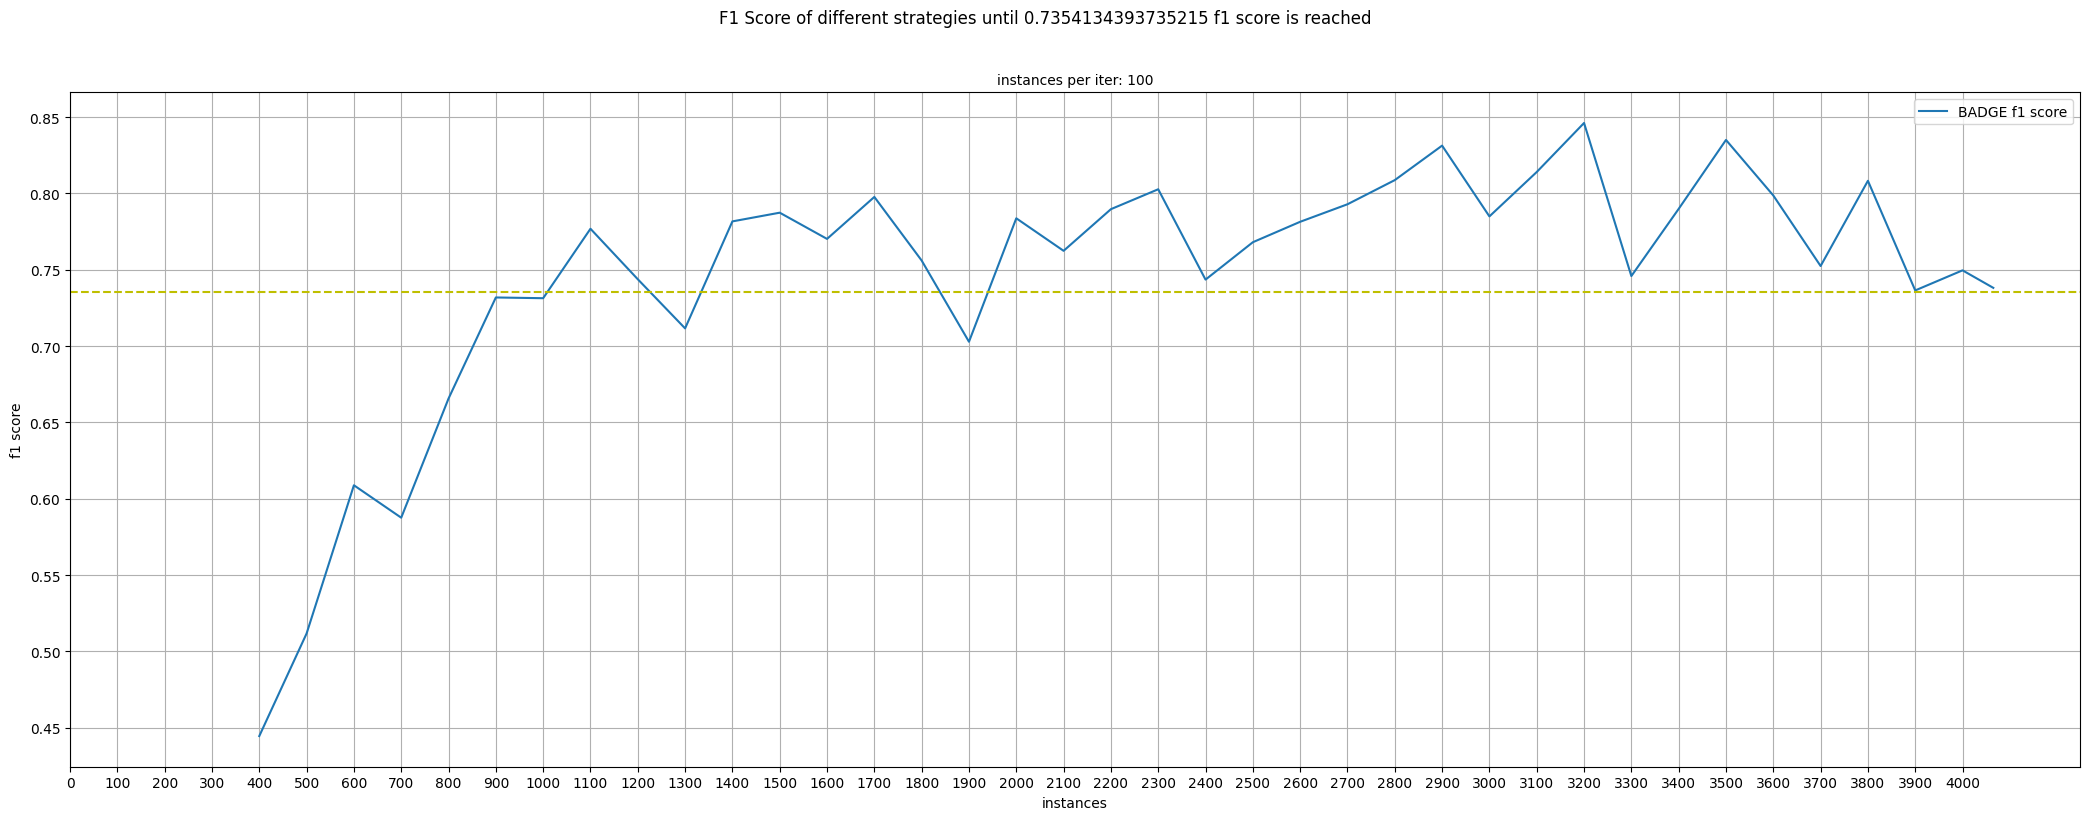

In [9]:
print(scores)


plot_results(
    scores,  # output data frame from strategy_comparison
    n_instances=n_instances,
    tot_samples=len(train_set),  # size of the original training set, for scale
    # goal_acc=goal_acc,
    figsize=(21, 8),
    goal_metric=goal_metric,
    goal_metric_val=goal_f1 if goal_metric == "f1" else goal_acc
)
